# AI-Powered Movie Recommendation System

This notebook builds a personalized movie recommendation system using
MovieLens user-rating data enriched with TMDB movie metadata.

The recommendation system will combine:

- content-based recommendations using genres and directors
- collaborative filtering using Pearson correlation
- user segmentation using SciPy k-means clustering
- hybrid recommendation scoring
- personalized recommendation explanations

The system is implemented using object-oriented programming to
demonstrate inheritance, encapsulation, and polymorphism.

In [1]:
# Data manipulation and plotting libraries used throughout the notebook.
from functools import reduce

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# SciPy supplies both the clustering algorithm and the hypothesis test.
from scipy.cluster.vq import kmeans, vq, whiten
from scipy.stats import wilcoxon

# Recommendation logic is kept in a module so the final demo can reuse it.
from recommender import (
    RecommendationEngine,
    ContentBasedRecommender,
    CollaborativeRecommender,
    ClusterRecommender,
    HybridRecommender,
    RecommendationExplainer
)

In [2]:
# Load the enriched rating-level dataset produced by notebook 01.
movie_ratings = pd.read_csv(
    "data/processed/movie_ratings.csv"
)

movie_ratings["watch_date"] = pd.to_datetime(
    movie_ratings["watch_date"],
    errors="coerce"
)

movie_ratings["release_date"] = pd.to_datetime(
    movie_ratings["release_date"],
    errors="coerce"
)

print(
    f"Ratings: {len(movie_ratings):,}"
)

print(
    f"Users: "
    f"{movie_ratings['userId'].nunique():,}"
)

print(
    f"Movies: "
    f"{movie_ratings['movieId'].nunique():,}"
)

Ratings: 100,836
Users: 610
Movies: 9,724


In [3]:
# Aggregate global quality and popularity signals once per movie.
movie_stats = (
    movie_ratings
    .groupby(
        ["movieId", "title"],
        as_index=False
    )
    .agg(
        average_rating=("rating", "mean"),
        rating_count=("rating", "count")
    )
)

movie_stats.head()

,movieId,title,average_rating,rating_count
0,1,Toy Story (1995),3.920930,215
1,2,Jumanji (1995),3.431818,110
2,3,Grumpier Old Men (1995),3.259615,52
3,4,Waiting to Exhale (1995),2.357143,7
4,5,Father of the Bride Part II (1995),3.071429,49


In [4]:
# Build one catalog row per movie and attach the aggregate statistics.
movie_catalog = (
    movie_ratings[
        [
            "movieId",
            "title",
            "genres",
            "director",
            "release_year",
            "runtime",
            "tmdb_rating",
            "popularity"
        ]
    ]
    .drop_duplicates(
        subset="movieId"
    )
    .merge(
        movie_stats,
        on=["movieId", "title"],
        how="left"
    )
)

movie_catalog.head()

,movieId,title,genres,director,release_year,runtime,tmdb_rating,popularity,average_rating,rating_count
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,John Lasseter,1995.0,81.0,8.000,41.0572,3.920930,215
1,3,Grumpier Old Men (1995),Comedy|Romance,Howard Deutch,1995.0,101.0,6.466,5.9315,3.259615,52
2,6,Heat (1995),Action|Crime|Thriller,Michael Mann,1995.0,170.0,7.941,23.1580,3.946078,102
3,47,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,David Fincher,1995.0,127.0,8.380,33.8713,3.975369,203
4,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,Bryan Singer,1995.0,106.0,8.165,21.1306,4.237745,204


In [5]:
# The base class centralizes validation and history lookup. Specialized
# recommenders inherit this behavior and override recommend().

In [6]:
# Instantiate the base class to demonstrate its shared helper methods.
base_engine = RecommendationEngine(
    movie_ratings,
    movie_catalog
)

In [7]:
user_id = 1

base_engine.get_user_history(
    user_id
)[
    [
        "title",
        "genres",
        "director",
        "rating"
    ]
].head(10)

,title,genres,director,rating
3,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,David Fincher,5.0
4,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,Bryan Singer,5.0
6,Bottle Rocket (1996),Adventure|Comedy|Crime|Romance,Wes Anderson,5.0
13,Dumb & Dumber (Dumb and Dumber) (1994),Adventure|Comedy,Peter Farrelly,5.0
11,Billy Madison (1995),Comedy,Tamra Davis,5.0
10,Desperado (1995),Action|Romance|Western,Robert Rodriguez,5.0
9,Canadian Bacon (1995),Comedy|War,Michael Moore,5.0
8,Rob Roy (1995),Action|Drama|Romance|War,Michael Caton-Jones,5.0
35,Pinocchio (1940),Animation|Children|Fantasy|Musical,Hamilton Luske | Ben Sharpsteen | T. Hee | Wil...,5.0
31,Tombstone (1993),Action|Drama|Western,George P. Cosmatos,5.0


In [8]:
# Convert multi-label genre strings into one row per user/movie/genre.
genre_ratings = movie_ratings.copy()

genre_ratings["genre"] = (
    genre_ratings["genres"]
    .str.split("|")
)

genre_ratings = genre_ratings.explode(
    "genre"
)

genre_ratings[
    [
        "userId",
        "title",
        "genre",
        "rating"
    ]
].head()

,userId,title,genre,rating
0,1,Toy Story (1995),Adventure,4.0
0,1,Toy Story (1995),Animation,4.0
0,1,Toy Story (1995),Children,4.0
0,1,Toy Story (1995),Comedy,4.0
0,1,Toy Story (1995),Fantasy,4.0


In [9]:
content_engine = ContentBasedRecommender(
    movie_ratings,
    movie_catalog
)

In [10]:
# Director preferences are implemented by ContentBasedRecommender in
# recommender.py. Displaying them here makes that input signal explicit.
content_engine.get_director_preferences(user_id).head(10)

,average_rating,movies_rated
director,,
Wolfgang Reitherman,5.0,4
David Fincher,5.0,3
Mel Brooks,5.0,3
Terence Young,5.0,3
Bryan Singer,5.0,2
Don Bluth,5.0,2
George Miller,5.0,2
Joel Coen | Ethan Coen,5.0,2
John Milius,5.0,2


## Content-Based Recommendation

The first recommendation approach uses the user's existing rating history
to infer preferences for genres and directors.

Movies the user has already rated are excluded.

Each candidate movie receives a recommendation score based on:

- the user's historical ratings for its genres
- the user's historical ratings for its director
- the movie's overall MovieLens average rating

A minimum number of ratings is also required to reduce the influence of
movies that have been rated by only a very small number of users.

In [11]:
user_id = 1

print("Top rated movies by User 1:")

display(
    content_engine
    .get_user_history(user_id)[
        [
            "title",
            "genres",
            "director",
            "rating"
        ]
    ]
    .head(15)
)

Top rated movies by User 1:


,title,genres,director,rating
3,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,David Fincher,5.0
4,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,Bryan Singer,5.0
6,Bottle Rocket (1996),Adventure|Comedy|Crime|Romance,Wes Anderson,5.0
13,Dumb & Dumber (Dumb and Dumber) (1994),Adventure|Comedy,Peter Farrelly,5.0
11,Billy Madison (1995),Comedy,Tamra Davis,5.0
10,Desperado (1995),Action|Romance|Western,Robert Rodriguez,5.0
9,Canadian Bacon (1995),Comedy|War,Michael Moore,5.0
8,Rob Roy (1995),Action|Drama|Romance|War,Michael Caton-Jones,5.0
35,Pinocchio (1940),Animation|Children|Fantasy|Musical,Hamilton Luske | Ben Sharpsteen | T. Hee | Wil...,5.0
31,Tombstone (1993),Action|Drama|Western,George P. Cosmatos,5.0


In [12]:
print("Genre preferences:")

display(
    content_engine
    .get_genre_preferences(
        user_id
    )
)

Genre preferences:


,average_rating,movies_rated
genre,,
Action,4.322222,90
Adventure,4.388235,85
Animation,4.689655,29
Children,4.547619,42
Comedy,4.277108,83
Crime,4.355556,45
Drama,4.529412,68
Fantasy,4.297872,47
Film-Noir,5.000000,1


In [13]:
recommendations = (
    content_engine.recommend(
        user_id=1,
        n=10,
        min_ratings=20
    )
)

recommendations

,movieId,title,genres,director,average_rating,rating_count,genre_score,director_score,content_score
232,318,"Shawshank Redemption, The (1994)",Crime|Drama,Frank Darabont,4.429022,317,4.442484,5.0,4.577151
1137,1228,Raging Bull (1980),Drama,Martin Scorsese,4.187500,40,4.529412,5.0,4.527390
2078,1233,"Boot, Das (Boat, The) (1981)",Action|Drama|War,Wolfgang Petersen,4.212500,40,4.450545,5.0,4.504593
2427,1104,"Streetcar Named Desire, A (1951)",Drama,Elia Kazan,4.475000,20,4.529412,NaN,4.504020
268,1272,Patton (1970),Drama|War,Franklin J. Schaffner,4.121212,33,4.514706,5.0,4.498307
830,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Drama|Film-Noir|Romance,Billy Wilder,4.333333,27,4.612368,NaN,4.482152
237,48516,"Departed, The (2006)",Crime|Drama|Thriller,Martin Scorsese,4.252336,107,4.343474,5.0,4.475707
1052,50872,Ratatouille (2007),Animation|Children|Drama,Brad Bird,3.868056,72,4.588895,5.0,4.439378
2394,953,It's a Wonderful Life (1946),Children|Drama|Fantasy|Romance,Frank Capra,4.034483,58,4.420649,5.0,4.430329
1093,111,Taxi Driver (1976),Crime|Drama|Thriller,Martin Scorsese,4.105769,104,4.343474,5.0,4.424409


In [14]:
recommendations[
    [
        "average_rating",
        "genre_score",
        "director_score",
        "content_score"
    ]
] = (
    recommendations[
        [
            "average_rating",
            "genre_score",
            "director_score",
            "content_score"
        ]
    ]
    .round(2)
)

recommendations

,movieId,title,genres,director,average_rating,rating_count,genre_score,director_score,content_score
232,318,"Shawshank Redemption, The (1994)",Crime|Drama,Frank Darabont,4.43,317,4.44,5.0,4.58
1137,1228,Raging Bull (1980),Drama,Martin Scorsese,4.19,40,4.53,5.0,4.53
2078,1233,"Boot, Das (Boat, The) (1981)",Action|Drama|War,Wolfgang Petersen,4.21,40,4.45,5.0,4.50
2427,1104,"Streetcar Named Desire, A (1951)",Drama,Elia Kazan,4.47,20,4.53,NaN,4.50
268,1272,Patton (1970),Drama|War,Franklin J. Schaffner,4.12,33,4.51,5.0,4.50
830,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Drama|Film-Noir|Romance,Billy Wilder,4.33,27,4.61,NaN,4.48
237,48516,"Departed, The (2006)",Crime|Drama|Thriller,Martin Scorsese,4.25,107,4.34,5.0,4.48
1052,50872,Ratatouille (2007),Animation|Children|Drama,Brad Bird,3.87,72,4.59,5.0,4.44
2394,953,It's a Wonderful Life (1946),Children|Drama|Fantasy|Romance,Frank Capra,4.03,58,4.42,5.0,4.43
1093,111,Taxi Driver (1976),Crime|Drama|Thriller,Martin Scorsese,4.11,104,4.34,5.0,4.42


## Collaborative Filtering with Pearson Correlation

Content-based recommendations use information about movies themselves.
Collaborative filtering instead identifies users who have similar rating
patterns.

For each user:

1. Find other users who rated some of the same movies.
2. Require a minimum number of movies in common.
3. Calculate Pearson correlation between their ratings.
4. Keep positively correlated users.
5. Find movies those similar users rated highly.
6. Exclude movies the target user has already seen.

This provides recommendations based on user behavior rather than movie
genres or directors.

In [15]:
collaborative_engine = CollaborativeRecommender(
    movie_ratings,
    movie_catalog
)

In [16]:
similar_users = (
    collaborative_engine
    .find_similar_users(
        user_id=1,
        min_common=10
    )
)

similar_users.head(10)

,userId,similarity,common_movies,p_value
0,476,0.786936,11,0.004052
1,210,0.767649,11,0.005807
2,297,0.706281,17,0.001530
3,44,0.684448,13,0.009861
4,394,0.650600,10,0.041646
5,248,0.624695,10,0.053493
6,369,0.612098,28,0.000537
7,72,0.596432,20,0.005507
8,344,0.587609,19,0.008154
9,112,0.583892,18,0.010953


In [17]:
similar_users_display = (
    similar_users
    .head(10)
    .copy()
)

similar_users_display[
    "similarity"
] = (
    similar_users_display[
        "similarity"
    ]
    .round(3)
)

similar_users_display[
    "p_value"
] = (
    similar_users_display[
        "p_value"
    ]
    .round(4)
)

similar_users_display

,userId,similarity,common_movies,p_value
0,476,0.787,11,0.0041
1,210,0.768,11,0.0058
2,297,0.706,17,0.0015
3,44,0.684,13,0.0099
4,394,0.651,10,0.0416
5,248,0.625,10,0.0535
6,369,0.612,28,0.0005
7,72,0.596,20,0.0055
8,344,0.588,19,0.0082
9,112,0.584,18,0.0110


In [18]:
collaborative_engine = CollaborativeRecommender(
    movie_ratings,
    movie_catalog
)

In [19]:
collaborative_recommendations = (
    collaborative_engine
    .recommend(
        user_id=1,
        n=10,
        min_common=10,
        n_similar_users=20,
        min_similarity=0.10,
        min_neighbor_ratings=3
    )
)

collaborative_recommendations

,movieId,title,genres,director,collaborative_score,similar_user_ratings,max_similarity,average_rating,rating_count
19,318,"Shawshank Redemption, The (1994)",Crime|Drama,Frank Darabont,5.000000,6,0.786936,4.429022,317
40,1193,One Flew Over the Cuckoo's Nest (1975),Drama,Miloš Forman,4.690002,5,0.596432,4.203008,133
102,112852,Guardians of the Galaxy (2014),Action|Adventure|Sci-Fi,James Gunn,4.559632,3,0.767649,4.050847,59
63,4973,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",Comedy|Romance,Jean-Pierre Jeunet,4.505911,6,0.596432,4.183333,120
67,5618,Spirited Away (Sen to Chihiro no kamikakushi) ...,Adventure|Animation|Fantasy,Hayao Miyazaki,4.500000,3,0.587609,4.155172,87
90,60684,Watchmen (2009),Action|Drama|Mystery|Sci-Fi|Thriller|IMAX,Zack Snyder,4.498251,3,0.587609,3.988372,43
97,79132,Inception (2010),Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX,Christopher Nolan,4.493270,4,0.583892,4.066434,143
64,4993,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy,Peter Jackson,4.471172,6,0.767649,4.106061,198
75,7153,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy,Peter Jackson,4.470908,6,0.767649,4.118919,185
104,122886,Star Wars: Episode VII - The Force Awakens (2015),Action|Adventure|Fantasy|Sci-Fi|IMAX,J.J. Abrams,4.419989,3,0.767649,3.853659,41


In [20]:
collaborative_recommendations[
    [
        "collaborative_score",
        "max_similarity",
        "average_rating"
    ]
] = (
    collaborative_recommendations[
        [
            "collaborative_score",
            "max_similarity",
            "average_rating"
        ]
    ]
    .round(2)
)

collaborative_recommendations

,movieId,title,genres,director,collaborative_score,similar_user_ratings,max_similarity,average_rating,rating_count
19,318,"Shawshank Redemption, The (1994)",Crime|Drama,Frank Darabont,5.00,6,0.79,4.43,317
40,1193,One Flew Over the Cuckoo's Nest (1975),Drama,Miloš Forman,4.69,5,0.60,4.20,133
102,112852,Guardians of the Galaxy (2014),Action|Adventure|Sci-Fi,James Gunn,4.56,3,0.77,4.05,59
63,4973,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",Comedy|Romance,Jean-Pierre Jeunet,4.51,6,0.60,4.18,120
67,5618,Spirited Away (Sen to Chihiro no kamikakushi) ...,Adventure|Animation|Fantasy,Hayao Miyazaki,4.50,3,0.59,4.16,87
90,60684,Watchmen (2009),Action|Drama|Mystery|Sci-Fi|Thriller|IMAX,Zack Snyder,4.50,3,0.59,3.99,43
97,79132,Inception (2010),Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX,Christopher Nolan,4.49,4,0.58,4.07,143
64,4993,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy,Peter Jackson,4.47,6,0.77,4.11,198
75,7153,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy,Peter Jackson,4.47,6,0.77,4.12,185
104,122886,Star Wars: Episode VII - The Force Awakens (2015),Action|Adventure|Fantasy|Sci-Fi|IMAX,J.J. Abrams,4.42,3,0.77,3.85,41


In [21]:
user_1_watched = (
    set(
        movie_ratings.loc[
            movie_ratings["userId"] == 1,
            "movieId"
        ]
    )
)

recommended_ids = set(
    collaborative_recommendations[
        "movieId"
    ]
)

overlap = (
    user_1_watched
    &
    recommended_ids
)

print(
    "Already watched movies recommended:",
    len(overlap)
)

Already watched movies recommended: 0


In [22]:
print("CONTENT-BASED RECOMMENDATIONS")

display(
    recommendations[
        [
            "title",
            "genres",
            "content_score"
        ]
    ]
)


print("\nCOLLABORATIVE RECOMMENDATIONS")

display(
    collaborative_recommendations[
        [
            "title",
            "genres",
            "collaborative_score",
            "similar_user_ratings"
        ]
    ]
)

CONTENT-BASED RECOMMENDATIONS


,title,genres,content_score
232,"Shawshank Redemption, The (1994)",Crime|Drama,4.58
1137,Raging Bull (1980),Drama,4.53
2078,"Boot, Das (Boat, The) (1981)",Action|Drama|War,4.50
2427,"Streetcar Named Desire, A (1951)",Drama,4.50
268,Patton (1970),Drama|War,4.50
830,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Drama|Film-Noir|Romance,4.48
237,"Departed, The (2006)",Crime|Drama|Thriller,4.48
1052,Ratatouille (2007),Animation|Children|Drama,4.44
2394,It's a Wonderful Life (1946),Children|Drama|Fantasy|Romance,4.43
1093,Taxi Driver (1976),Crime|Drama|Thriller,4.42



COLLABORATIVE RECOMMENDATIONS


,title,genres,collaborative_score,similar_user_ratings
19,"Shawshank Redemption, The (1994)",Crime|Drama,5.00,6
40,One Flew Over the Cuckoo's Nest (1975),Drama,4.69,5
102,Guardians of the Galaxy (2014),Action|Adventure|Sci-Fi,4.56,3
63,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",Comedy|Romance,4.51,6
67,Spirited Away (Sen to Chihiro no kamikakushi) ...,Adventure|Animation|Fantasy,4.50,3
90,Watchmen (2009),Action|Drama|Mystery|Sci-Fi|Thriller|IMAX,4.50,3
97,Inception (2010),Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX,4.49,4
64,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy,4.47,6
75,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy,4.47,6
104,Star Wars: Episode VII - The Force Awakens (2015),Action|Adventure|Fantasy|Sci-Fi|IMAX,4.42,3


In [23]:
content_titles = set(
    recommendations["title"]
)

collaborative_titles = set(
    collaborative_recommendations["title"]
)

overlap = (
    content_titles
    & collaborative_titles
)

print(
    f"Movies recommended by both systems: "
    f"{len(overlap)}"
)

for movie in overlap:
    print("-", movie)

Movies recommended by both systems: 1
- Shawshank Redemption, The (1994)


In [24]:
collaborative_recommendations[
    [
        "title",
        "collaborative_score",
        "similar_user_ratings",
        "max_similarity"
    ]
]

,title,collaborative_score,similar_user_ratings,max_similarity
19,"Shawshank Redemption, The (1994)",5.00,6,0.79
40,One Flew Over the Cuckoo's Nest (1975),4.69,5,0.60
102,Guardians of the Galaxy (2014),4.56,3,0.77
63,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",4.51,6,0.60
67,Spirited Away (Sen to Chihiro no kamikakushi) ...,4.50,3,0.59
90,Watchmen (2009),4.50,3,0.59
97,Inception (2010),4.49,4,0.58
64,"Lord of the Rings: The Fellowship of the Ring,...",4.47,6,0.77
75,"Lord of the Rings: The Return of the King, The...",4.47,6,0.77
104,Star Wars: Episode VII - The Force Awakens (2015),4.42,3,0.77


In [25]:
collaborative_display = (
    collaborative_recommendations.copy()
)

collaborative_display[
    [
        "collaborative_score",
        "max_similarity",
        "average_rating"
    ]
] = (
    collaborative_display[
        [
            "collaborative_score",
            "max_similarity",
            "average_rating"
        ]
    ]
    .round(2)
)

collaborative_display

,movieId,title,genres,director,collaborative_score,similar_user_ratings,max_similarity,average_rating,rating_count
19,318,"Shawshank Redemption, The (1994)",Crime|Drama,Frank Darabont,5.00,6,0.79,4.43,317
40,1193,One Flew Over the Cuckoo's Nest (1975),Drama,Miloš Forman,4.69,5,0.60,4.20,133
102,112852,Guardians of the Galaxy (2014),Action|Adventure|Sci-Fi,James Gunn,4.56,3,0.77,4.05,59
63,4973,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",Comedy|Romance,Jean-Pierre Jeunet,4.51,6,0.60,4.18,120
67,5618,Spirited Away (Sen to Chihiro no kamikakushi) ...,Adventure|Animation|Fantasy,Hayao Miyazaki,4.50,3,0.59,4.16,87
90,60684,Watchmen (2009),Action|Drama|Mystery|Sci-Fi|Thriller|IMAX,Zack Snyder,4.50,3,0.59,3.99,43
97,79132,Inception (2010),Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX,Christopher Nolan,4.49,4,0.58,4.07,143
64,4993,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy,Peter Jackson,4.47,6,0.77,4.11,198
75,7153,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy,Peter Jackson,4.47,6,0.77,4.12,185
104,122886,Star Wars: Episode VII - The Force Awakens (2015),Action|Adventure|Fantasy|Sci-Fi|IMAX,J.J. Abrams,4.42,3,0.77,3.85,41


In [26]:
content_titles = set(
    recommendations["title"]
)

collaborative_titles = set(
    collaborative_recommendations["title"]
)

overlap = (
    content_titles
    & collaborative_titles
)

print(
    f"Recommendations shared by both systems: "
    f"{len(overlap)}"
)

for title in overlap:
    print("-", title)

Recommendations shared by both systems: 1
- Shawshank Redemption, The (1994)


The relatively low overlap shows that the two algorithms capture different aspects of user preference. Content-based filtering emphasizes similarity to the user's historical genre and director preferences, while collaborative filtering introduces movies favored by users with similar rating patterns.

Combining these complementary signals may produce more robust recommendations.

## User Clustering with SciPy K-Means

The third recommendation approach groups users with similar genre-rating
patterns.

Instead of comparing users one-by-one, k-means identifies broader groups
of users whose preferences are similar.

To reduce the effect of users who naturally rate everything higher or
lower, genre preference is calculated relative to each user's overall
average rating.

A positive genre preference score means the user tends to rate that genre
above their personal average, while a negative score means they tend to
rate it below their personal average.

In [27]:
# Convert multi-label genres to one feature row per user/movie/genre.
cluster_genre_data = movie_ratings[
    [
        "userId",
        "movieId",
        "genres",
        "rating"
    ]
].copy()

cluster_genre_data["genre"] = (
    cluster_genre_data["genres"]
    .str.split("|")
)

cluster_genre_data = (
    cluster_genre_data
    .explode("genre")
)

cluster_genre_data.head()

,userId,movieId,genres,rating,genre
0,1,1,Adventure|Animation|Children|Comedy|Fantasy,4.0,Adventure
0,1,1,Adventure|Animation|Children|Comedy|Fantasy,4.0,Animation
0,1,1,Adventure|Animation|Children|Comedy|Fantasy,4.0,Children
0,1,1,Adventure|Animation|Children|Comedy|Fantasy,4.0,Comedy
0,1,1,Adventure|Animation|Children|Comedy|Fantasy,4.0,Fantasy


In [28]:
user_average_rating = (
    movie_ratings
    .groupby("userId")["rating"]
    .mean()
)

user_average_rating.head()

userId
1    4.366379
2    3.948276
3    2.435897
4    3.555556
5    3.636364
Name: rating, dtype: float64

In [29]:
user_genre_ratings = (
    cluster_genre_data
    .groupby(
        ["userId", "genre"]
    )["rating"]
    .mean()
    .unstack()
)

user_genre_ratings.head()

genre,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
userId,,,,,,,,,,,,,,,,,,,,
1,NaN,4.322222,4.388235,4.689655,4.547619,4.277108,4.355556,NaN,4.529412,4.297872,5.0,3.470588,NaN,4.681818,4.166667,4.307692,4.225000,4.145455,4.500000,4.285714
2,NaN,3.954545,4.166667,NaN,NaN,4.000000,3.800000,4.333333,3.882353,NaN,NaN,3.000000,3.750000,NaN,4.000000,4.500000,3.875000,3.700000,4.500000,3.500000
3,NaN,3.571429,2.727273,0.500000,0.500000,1.000000,0.500000,NaN,0.750000,3.375000,NaN,4.687500,NaN,0.500000,5.000000,0.500000,4.200000,4.142857,0.500000,NaN
4,NaN,3.320000,3.655172,4.000000,3.800000,3.509615,3.814815,4.000000,3.483333,3.684211,4.0,4.250000,3.000000,4.000000,3.478261,3.379310,2.833333,3.552632,3.571429,3.800000
5,NaN,3.111111,3.250000,4.333333,4.111111,3.466667,3.833333,NaN,3.800000,4.142857,NaN,3.000000,3.666667,4.400000,4.000000,3.090909,2.500000,3.555556,3.333333,3.000000


In [30]:
user_genre_preferences = (
    user_genre_ratings
    .sub(
        user_average_rating,
        axis=0
    )
)

In [31]:
user_genre_preferences.head()

genre,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
userId,,,,,,,,,,,,,,,,,,,,
1,NaN,-0.044157,0.021856,0.323276,0.181240,-0.089271,-0.010824,NaN,0.163032,-0.068507,0.633621,-0.895791,NaN,0.315439,-0.199713,-0.058687,-0.141379,-0.220925,0.133621,-0.080665
2,NaN,0.006270,0.218391,NaN,NaN,0.051724,-0.148276,0.385057,-0.065923,NaN,NaN,-0.948276,-0.198276,NaN,0.051724,0.551724,-0.073276,-0.248276,0.551724,-0.448276
3,NaN,1.135531,0.291375,-1.935897,-1.935897,-1.435897,-1.935897,NaN,-1.685897,0.939103,NaN,2.251603,NaN,-1.935897,2.564103,-1.935897,1.764103,1.706960,-1.935897,NaN
4,NaN,-0.235556,0.099617,0.444444,0.244444,-0.045940,0.259259,0.444444,-0.072222,0.128655,0.444444,0.694444,-0.555556,0.444444,-0.077295,-0.176245,-0.722222,-0.002924,0.015873,0.244444
5,NaN,-0.525253,-0.386364,0.696970,0.474747,-0.169697,0.196970,NaN,0.163636,0.506494,NaN,-0.636364,0.030303,0.763636,0.363636,-0.545455,-1.136364,-0.080808,-0.303030,-0.636364


In [32]:
user_genre_preferences = (
    user_genre_preferences
    .fillna(0)
)

In [33]:
if "(no genres listed)" in user_genre_preferences.columns:

    user_genre_preferences = (
        user_genre_preferences
        .drop(
            columns="(no genres listed)"
        )
    )

In [34]:
user_genre_preferences.head()

genre,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
userId,,,,,,,,,,,,,,,,,,,
1,-0.044157,0.021856,0.323276,0.181240,-0.089271,-0.010824,0.000000,0.163032,-0.068507,0.633621,-0.895791,0.000000,0.315439,-0.199713,-0.058687,-0.141379,-0.220925,0.133621,-0.080665
2,0.006270,0.218391,0.000000,0.000000,0.051724,-0.148276,0.385057,-0.065923,0.000000,0.000000,-0.948276,-0.198276,0.000000,0.051724,0.551724,-0.073276,-0.248276,0.551724,-0.448276
3,1.135531,0.291375,-1.935897,-1.935897,-1.435897,-1.935897,0.000000,-1.685897,0.939103,0.000000,2.251603,0.000000,-1.935897,2.564103,-1.935897,1.764103,1.706960,-1.935897,0.000000
4,-0.235556,0.099617,0.444444,0.244444,-0.045940,0.259259,0.444444,-0.072222,0.128655,0.444444,0.694444,-0.555556,0.444444,-0.077295,-0.176245,-0.722222,-0.002924,0.015873,0.244444
5,-0.525253,-0.386364,0.696970,0.474747,-0.169697,0.196970,0.000000,0.163636,0.506494,0.000000,-0.636364,0.030303,0.763636,0.363636,-0.545455,-1.136364,-0.080808,-0.303030,-0.636364


In [35]:
user_genre_preferences.loc[1].sort_values(
    ascending=False
)

genre
Film-Noir      0.633621
Animation      0.323276
Musical        0.315439
Children       0.181240
Drama          0.163032
War            0.133621
Adventure      0.021856
Documentary    0.000000
IMAX           0.000000
Crime         -0.010824
Action        -0.044157
Romance       -0.058687
Fantasy       -0.068507
Western       -0.080665
Comedy        -0.089271
Sci-Fi        -0.141379
Mystery       -0.199713
Thriller      -0.220925
Horror        -0.895791
Name: 1, dtype: float64

In [36]:
cluster_features = (
    user_genre_preferences
    .values
    .astype(float)
)

print(
    "Users:",
    cluster_features.shape[0]
)

print(
    "Genre features:",
    cluster_features.shape[1]
)

Users: 610
Genre features: 19


In [37]:
# Scale features so high-variance genres do not dominate distance.
cluster_features_whitened = whiten(
    cluster_features
)

cluster_features_whitened.shape

(610, 19)

In [38]:
cluster_results = []

for k in range(2, 9):

    centroids, distortion = kmeans(
        cluster_features_whitened,
        k,
        iter=30,
        rng=42
    )

    cluster_results.append(
        {
            "k": k,
            "distortion": distortion
        }
    )


cluster_evaluation = pd.DataFrame(
    cluster_results
)

cluster_evaluation

,k,distortion
0,2,3.713638
1,3,3.633149
2,4,3.571358
3,5,3.512246
4,6,3.471744
5,7,3.427353
6,8,3.393792


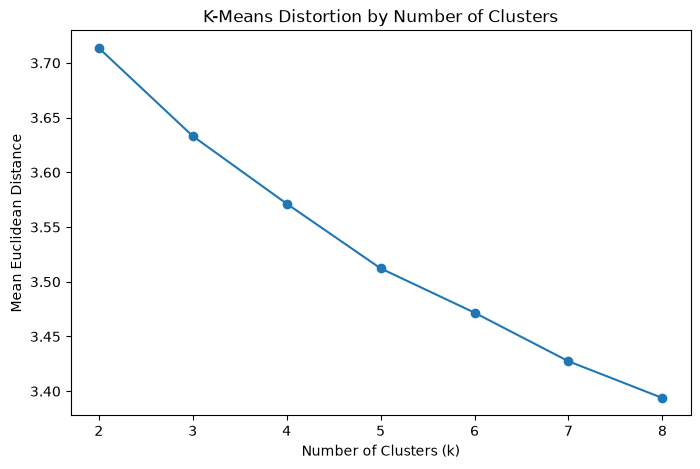

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    cluster_evaluation["k"],
    cluster_evaluation["distortion"],
    marker="o"
)

plt.title(
    "K-Means Distortion by Number of Clusters"
)

plt.xlabel(
    "Number of Clusters (k)"
)

plt.ylabel(
    "Mean Euclidean Distance"
)

plt.xticks(
    cluster_evaluation["k"]
)

plt.show()

### Selecting the Number of Clusters

The distortion decreases steadily as the number of clusters increases,
without a very sharp elbow.

A value of **k = 5** was selected as a practical compromise. Beyond five
clusters, the reduction in distortion becomes smaller, while additional
clusters would make the user segments more difficult to interpret.

The resulting clusters will be examined to confirm that they contain
meaningful differences in genre preferences.

In [40]:
N_CLUSTERS = 5

centroids, distortion = kmeans(
    cluster_features_whitened,
    N_CLUSTERS,
    iter=50,
    rng=42
)

cluster_labels, distances = vq(
    cluster_features_whitened,
    centroids
)

print(
    f"Final distortion: {distortion:.4f}"
)

print(
    f"Number of clusters: {N_CLUSTERS}"
)

Final distortion: 3.5122
Number of clusters: 5


In [41]:
user_clusters = pd.DataFrame(
    {
        "userId": user_genre_preferences.index,
        "cluster": cluster_labels
    }
)

user_clusters.head()

,userId,cluster
0,1,2
1,2,2
2,3,3
3,4,0
4,5,0


In [42]:
cluster_sizes = (
    user_clusters["cluster"]
    .value_counts()
    .sort_index()
)

cluster_sizes

cluster
0    141
1    204
2    142
3     66
4     57
Name: count, dtype: int64

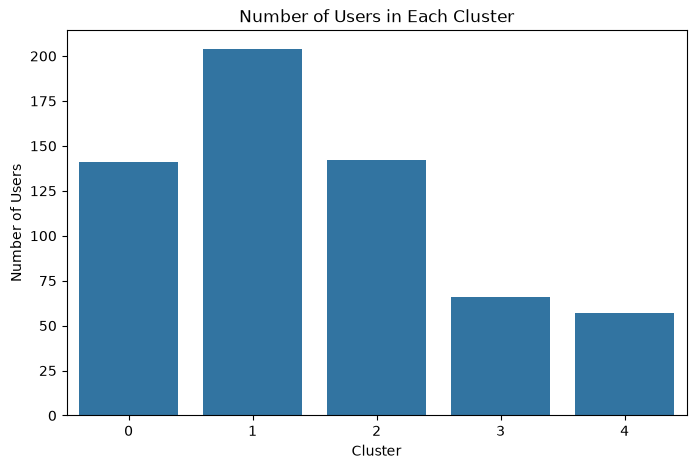

In [43]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_sizes.index,
    y=cluster_sizes.values
)

plt.title("Number of Users in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Users")

plt.show()

In [44]:
cluster_profiles = (
    user_genre_preferences
    .copy()
)

cluster_profiles["cluster"] = (
    cluster_labels
)

cluster_profiles.head()

genre,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,cluster
userId,,,,,,,,,,,,,,,,,,,,
1,-0.044157,0.021856,0.323276,0.181240,-0.089271,-0.010824,0.000000,0.163032,-0.068507,0.633621,-0.895791,0.000000,0.315439,-0.199713,-0.058687,-0.141379,-0.220925,0.133621,-0.080665,2
2,0.006270,0.218391,0.000000,0.000000,0.051724,-0.148276,0.385057,-0.065923,0.000000,0.000000,-0.948276,-0.198276,0.000000,0.051724,0.551724,-0.073276,-0.248276,0.551724,-0.448276,2
3,1.135531,0.291375,-1.935897,-1.935897,-1.435897,-1.935897,0.000000,-1.685897,0.939103,0.000000,2.251603,0.000000,-1.935897,2.564103,-1.935897,1.764103,1.706960,-1.935897,0.000000,3
4,-0.235556,0.099617,0.444444,0.244444,-0.045940,0.259259,0.444444,-0.072222,0.128655,0.444444,0.694444,-0.555556,0.444444,-0.077295,-0.176245,-0.722222,-0.002924,0.015873,0.244444,0
5,-0.525253,-0.386364,0.696970,0.474747,-0.169697,0.196970,0.000000,0.163636,0.506494,0.000000,-0.636364,0.030303,0.763636,0.363636,-0.545455,-1.136364,-0.080808,-0.303030,-0.636364,0


In [45]:
cluster_genre_profiles = (
    cluster_profiles
    .groupby("cluster")
    .mean()
)

cluster_genre_profiles

genre,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
cluster,,,,,,,,,,,,,,,,,,,
0,-0.294615,-0.302691,0.007987,-0.118962,0.000487,0.124463,-0.059267,0.180291,-0.250252,0.174620,0.025471,-0.309605,0.104718,0.169047,0.083797,-0.357188,-0.075362,0.230149,-0.022114
1,0.080712,0.090283,0.070783,-0.062720,-0.161606,0.120581,-0.026811,0.030117,-0.054776,-0.038774,-0.027991,0.204244,-0.008880,0.134477,-0.160589,0.122334,0.089655,0.091030,0.003216
2,-0.137340,-0.004482,0.227061,0.008881,-0.078409,0.148508,0.344429,0.172658,0.069804,0.323393,-0.516328,0.322989,0.190612,0.099461,0.101855,-0.227550,-0.064344,0.386132,0.054648
3,-0.088762,-0.234541,-1.057736,-1.098962,-0.294881,0.284867,0.049640,0.165811,-0.515831,0.085993,0.046307,0.002350,-0.897430,0.296880,-0.176026,-0.069192,0.192993,0.113847,0.026787
4,-0.207944,0.292858,0.347612,0.293516,0.159834,-0.392061,-0.014000,-0.110074,0.375500,-0.247982,-0.418799,0.233349,0.141099,-0.496843,0.122643,-0.243823,-0.536153,0.010649,-0.009533


In [46]:
for cluster_id in cluster_genre_profiles.index:

    print(
        f"\nCluster {cluster_id}"
    )

    top_genres = (
        cluster_genre_profiles
        .loc[cluster_id]
        .sort_values(
            ascending=False
        )
        .head(5)
    )

    display(top_genres)


Cluster 0


genre
War          0.230149
Drama        0.180291
Film-Noir    0.174620
Mystery      0.169047
Crime        0.124463
Name: 0, dtype: float64


Cluster 1


genre
IMAX       0.204244
Mystery    0.134477
Sci-Fi     0.122334
Crime      0.120581
War        0.091030
Name: 1, dtype: float64


Cluster 2


genre
War            0.386132
Documentary    0.344429
Film-Noir      0.323393
IMAX           0.322989
Animation      0.227061
Name: 2, dtype: float64


Cluster 3


genre
Mystery     0.296880
Crime       0.284867
Thriller    0.192993
Drama       0.165811
War         0.113847
Name: 3, dtype: float64


Cluster 4


genre
Fantasy      0.375500
Animation    0.347612
Children     0.293516
Adventure    0.292858
IMAX         0.233349
Name: 4, dtype: float64

In [47]:
cluster_sizes = (
    user_clusters["cluster"]
    .value_counts()
    .sort_index()
)

cluster_sizes

cluster
0    141
1    204
2    142
3     66
4     57
Name: count, dtype: int64

In [48]:
user_rating_counts = (
    movie_ratings
    .groupby("userId")
    .size()
    .rename("ratings_count")
)

cluster_activity = (
    user_clusters
    .set_index("userId")
    .join(user_rating_counts)
    .groupby("cluster")["ratings_count"]
    .agg(["count", "mean", "median", "min", "max"])
)

cluster_activity.round(1)

,count,mean,median,min,max
cluster,,,,,
0,141,146.6,76.0,21,1115
1,204,114.9,58.0,20,831
2,142,324.4,134.5,22,2698
3,66,75.1,48.0,20,366
4,57,99.9,48.0,20,763


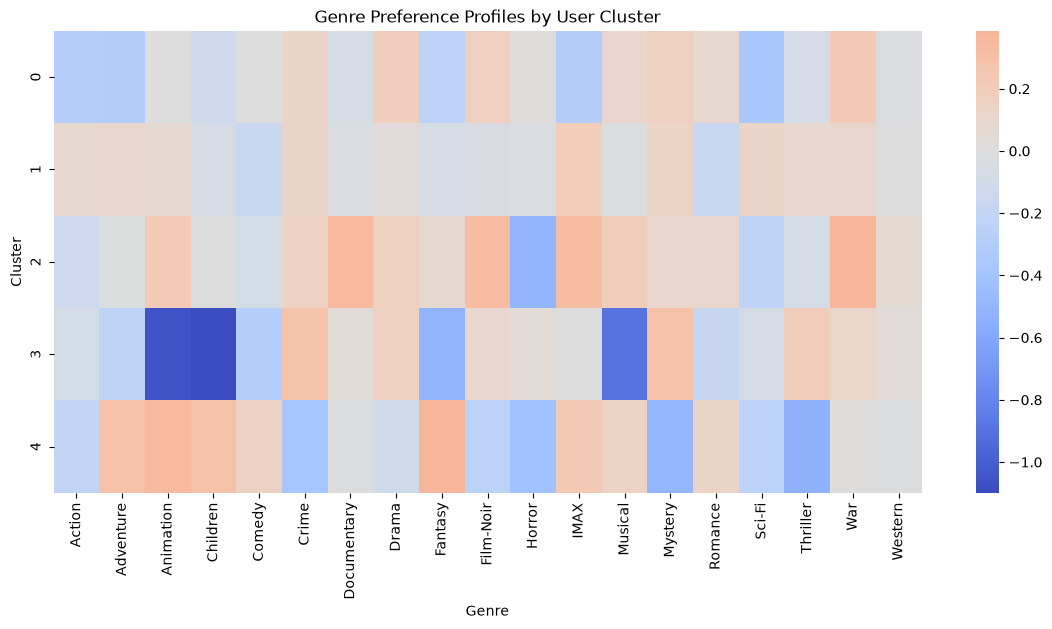

In [49]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    cluster_genre_profiles,
    cmap="coolwarm",
    center=0
)

plt.title("Genre Preference Profiles by User Cluster")
plt.xlabel("Genre")
plt.ylabel("Cluster")

plt.show()

### Cluster Analysis

The five-cluster solution produces reasonably sized and interpretable
groups of users.

- **Cluster 0:** stronger preferences for Drama, War, Film-Noir and Mystery.
- **Cluster 1:** a more general profile with moderate preferences for IMAX,
  Mystery, Sci-Fi and Crime.
- **Cluster 2:** highly active users with broad viewing histories and stronger
  preferences for War, Documentary, Film-Noir and IMAX.
- **Cluster 3:** strongly oriented toward Crime, Mystery and Thriller, while
  showing relatively low preference for Animation and Children genres.
- **Cluster 4:** strongly oriented toward Fantasy, Animation, Children and
  Adventure.

Cluster 2 contains the most active users on average, suggesting that its
broader genre profile reflects greater viewing diversity rather than sparse
rating histories.

The clusters can now be used as an additional recommendation signal by
identifying highly rated movies among users belonging to the same cluster.

In [50]:
cluster_engine = ClusterRecommender(
    movie_ratings,
    movie_catalog,
    user_clusters
)

In [51]:
user_id = 1

print(
    f"User {user_id} belongs to cluster:",
    cluster_engine.get_user_cluster(
        user_id
    )
)

User 1 belongs to cluster: 2


In [52]:
cluster_members = (
    cluster_engine
    .get_cluster_users(
        user_id
    )
)

print(
    "Other users in cluster:",
    len(cluster_members)
)

Other users in cluster: 141


In [53]:
cluster_recommendations = (
    cluster_engine
    .recommend(
        user_id=1,
        n=10,
        min_cluster_ratings=10
    )
)

cluster_recommendations

,movieId,title,genres,director,user_cluster,cluster_score,cluster_rating_count,average_rating,rating_count
532,3030,Yojimbo (1961),Action|Adventure,Akira Kurosawa,2,4.650000,10,4.230769,13
88,318,"Shawshank Redemption, The (1994)",Crime|Drama,Frank Darabont,2,4.558824,85,4.429022,317
66,246,Hoop Dreams (1994),Documentary,Steve James,2,4.500000,15,4.293103,29
246,1204,Lawrence of Arabia (1962),Adventure|Drama|War,David Lean,2,4.478261,23,4.300000,45
720,4973,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",Comedy|Romance,Jean-Pierre Jeunet,2,4.439024,41,4.183333,120
666,4226,Memento (2000),Mystery|Thriller,Christopher Nolan,2,4.427273,55,4.122642,159
169,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,Stanley Kubrick,2,4.419355,31,4.268041,97
252,1223,"Grand Day Out with Wallace and Gromit, A (1989)",Adventure|Animation|Children|Comedy|Sci-Fi,Nick Park,2,4.411765,17,4.089286,28
399,2019,Seven Samurai (Shichinin no samurai) (1954),Action|Adventure|Drama,Akira Kurosawa,2,4.400000,20,4.187500,48
207,951,His Girl Friday (1940),Comedy|Romance,Howard Hawks,2,4.400000,10,4.392857,14


## Comparing the Three Recommendation Approaches

The recommendation system now uses three different approaches:

- **Content-based filtering** identifies movies matching the user's
  historical genre and director preferences.
- **Collaborative filtering** identifies movies liked by users with
  similar rating patterns using Pearson correlation.
- **Cluster-based filtering** identifies highly rated movies among users
  belonging to the same k-means preference cluster.

Because the methods use different information, agreement between multiple
models can provide additional evidence that a movie is a strong
recommendation.

In [54]:
content_set = set(
    recommendations["movieId"]
)

collaborative_set = set(
    collaborative_recommendations["movieId"]
)

cluster_set = set(
    cluster_recommendations["movieId"]
)


all_three = (
    content_set
    & collaborative_set
    & cluster_set
)

content_collaborative = (
    content_set
    & collaborative_set
)

content_cluster = (
    content_set
    & cluster_set
)

collaborative_cluster = (
    collaborative_set
    & cluster_set
)


print(
    "Movies recommended by all three systems:",
    len(all_three)
)

print(
    "Content + Collaborative overlap:",
    len(content_collaborative)
)

print(
    "Content + Cluster overlap:",
    len(content_cluster)
)

print(
    "Collaborative + Cluster overlap:",
    len(collaborative_cluster)
)

Movies recommended by all three systems: 1
Content + Collaborative overlap: 1
Content + Cluster overlap: 1
Collaborative + Cluster overlap: 2


In [55]:
if all_three:

    shared_movies = (
        movie_catalog[
            movie_catalog["movieId"]
            .isin(all_three)
        ][
            [
                "title",
                "genres",
                "average_rating",
                "rating_count"
            ]
        ]
    )

    display(shared_movies)

else:

    print(
        "No movie appears in all three top-10 lists."
    )

,title,genres,average_rating,rating_count
232,"Shawshank Redemption, The (1994)",Crime|Drama,4.429022,317


In [56]:
comparison_movies = (
    content_set
    | collaborative_set
    | cluster_set
)

comparison = (
    movie_catalog[
        movie_catalog["movieId"]
        .isin(comparison_movies)
    ][
        [
            "movieId",
            "title"
        ]
    ]
    .copy()
)


comparison["content"] = (
    comparison["movieId"]
    .isin(content_set)
)

comparison["collaborative"] = (
    comparison["movieId"]
    .isin(collaborative_set)
)

comparison["cluster"] = (
    comparison["movieId"]
    .isin(cluster_set)
)


comparison["models_recommending"] = (
    comparison[
        [
            "content",
            "collaborative",
            "cluster"
        ]
    ]
    .sum(axis=1)
)


comparison = (
    comparison
    .sort_values(
        [
            "models_recommending",
            "title"
        ],
        ascending=[
            False,
            True
        ]
    )
)

comparison

,movieId,title,content,collaborative,cluster,models_recommending
232,318,"Shawshank Redemption, The (1994)",True,True,True,3
1125,4973,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",False,True,True,2
2078,1233,"Boot, Das (Boat, The) (1981)",True,False,False,1
237,48516,"Departed, The (2006)",True,False,False,1
722,750,Dr. Strangelove or: How I Learned to Stop Worr...,False,False,True,1
1104,1223,"Grand Day Out with Wallace and Gromit, A (1989)",False,False,True,1
1077,112852,Guardians of the Galaxy (2014),False,True,False,1
3008,951,His Girl Friday (1940),False,False,True,1
2424,246,Hoop Dreams (1994),False,False,True,1
244,79132,Inception (2010),False,True,False,1


## Hybrid Recommendation System

The three recommendation approaches capture different aspects of user preference:

- **Content-based filtering** measures how well movies match the user's
  genre and director preferences.
- **Collaborative filtering** uses Pearson correlation to identify movies
  liked by users with similar rating behavior.
- **Cluster-based filtering** uses k-means segmentation to identify movies
  that are highly rated within the user's broader preference group.

The hybrid recommender combines these signals into a final recommendation
score.

Because the three algorithms produce scores with different meanings, their
scores are first converted to percentile ranks between 0 and 1. This allows
the models to be combined on a comparable scale.

The initial hybrid weights are:

- Content-based: **40%**
- Collaborative: **40%**
- Cluster-based: **20%**

Movies recommended by multiple models naturally receive stronger combined
scores.

In [57]:
hybrid_engine = HybridRecommender(
    movie_ratings,
    movie_catalog,
    content_engine,
    collaborative_engine,
    cluster_engine
)

In [58]:
hybrid_recommendations = (
    hybrid_engine
    .recommend(
        user_id=1,
        n=10
    )
)

hybrid_recommendations

,movieId,title,genres,director,hybrid_score,models_recommending,content_score,collaborative_score,cluster_score,average_rating,rating_count
14,318,"Shawshank Redemption, The (1994)",Crime|Drama,Frank Darabont,0.998,3,4.577151,4.820982,4.558824,4.429022,317
155,48516,"Departed, The (2006)",Crime|Drama|Thriller,Martin Scorsese,0.933,3,4.475707,4.663717,4.333333,4.252336,107
51,1193,One Flew Over the Cuckoo's Nest (1975),Drama,Miloš Forman,0.832,3,4.377090,4.583002,4.295455,4.203008,133
37,912,Casablanca (1942),Drama|Romance,Michael Curtiz,0.826,3,4.335228,4.745493,4.380952,4.240000,100
126,5618,Spirited Away (Sen to Chihiro no kamikakushi) ...,Adventure|Animation|Fantasy,Hayao Miyazaki,0.652,3,4.316994,4.614645,4.155172,4.155172,87
203,112552,Whiplash (2014),Drama,Damien Chazelle,0.650,3,4.300774,4.497252,4.318182,4.039474,38
132,5995,"Pianist, The (2002)",Drama|War,Roman Polanski,0.620,3,4.325234,4.153449,4.392857,4.108696,46
30,858,"Godfather, The (1972)",Crime|Drama,Francis Ford Coppola,0.564,3,4.278165,4.498010,4.379630,4.289062,192
12,293,Léon: The Professional (a.k.a. The Professiona...,Action|Crime|Drama|Thriller,Luc Besson,0.560,3,4.391843,4.148468,4.107143,4.018797,133
55,1204,Lawrence of Arabia (1962),Adventure|Drama|War,David Lean,0.534,2,4.392026,NaN,4.478261,4.300000,45


### Hybrid Recommendation Results

The hybrid system combines the three recommendation approaches into a
single ranked list.

Several of the highest-ranked movies are supported by all three models.
For example, *The Shawshank Redemption* receives strong content-based,
collaborative, and cluster-based scores and therefore ranks first in the
hybrid recommendations.

Movies supported by fewer models can still appear in the final list when
they receive particularly strong scores from the available recommendation
methods.

The hybrid score represents relative recommendation strength rather than
a predicted movie rating.

## Personalized Recommendation Explanations

To simulate the personalized content generation used by AI-powered media
applications, the system generates a short explanation for each
recommendation.

The explanation uses information from the user's actual rating history and
the recommendation models. It can reference:

- a highly rated movie from the user's history with similar genres
- the user's preferred genres
- recommendations from users with similar rating patterns
- recommendations from the user's k-means cluster

This produces human-readable recommendations such as:

> "Since you rated a similar Crime and Drama movie highly, you might enjoy
> The Shawshank Redemption. It is also strongly recommended by users with
> similar preferences."

In [59]:
explainer = RecommendationExplainer(
    movie_ratings
)

In [60]:
first_recommendation = (
    hybrid_recommendations.iloc[0]
)

explanation = (
    explainer
    .generate_explanation(
        user_id=1,
        recommendation=first_recommendation
    )
)

print(explanation)

Since you rated Goodfellas (1990) 5.0/5 and it shares Crime and Drama elements, you might enjoy Shawshank Redemption, The (1994). It is supported by all three recommendation models: your content preferences, similar users, and your k-means user cluster.


In [61]:
hybrid_with_explanations = (
    hybrid_recommendations.copy()
)


hybrid_with_explanations[
    "explanation"
] = (
    hybrid_with_explanations
    .apply(
        lambda row:
        explainer.generate_explanation(
            user_id=1,
            recommendation=row
        ),
        axis=1
    )
)

In [62]:
for _, movie in (
    hybrid_with_explanations
    .iterrows()
):

    print(
        f"\n{movie['title']}"
    )

    print(
        f"Hybrid score: "
        f"{movie['hybrid_score']:.3f}"
    )

    print(
        movie["explanation"]
    )


Shawshank Redemption, The (1994)
Hybrid score: 0.998
Since you rated Goodfellas (1990) 5.0/5 and it shares Crime and Drama elements, you might enjoy Shawshank Redemption, The (1994). It is supported by all three recommendation models: your content preferences, similar users, and your k-means user cluster.

Departed, The (2006)
Hybrid score: 0.933
Since you rated Few Good Men, A (1992) 4.0/5 and it shares Crime and Drama and Thriller elements, you might enjoy Departed, The (2006). It is supported by all three recommendation models: your content preferences, similar users, and your k-means user cluster.

One Flew Over the Cuckoo's Nest (1975)
Hybrid score: 0.832
Since you rated Mr. Smith Goes to Washington (1939) 5.0/5 and it shares Drama elements, you might enjoy One Flew Over the Cuckoo's Nest (1975). It is supported by all three recommendation models: your content preferences, similar users, and your k-means user cluster.

Casablanca (1942)
Hybrid score: 0.826
Since you rated Quiet M

## Statistical Analysis: Do Genre Preferences Predict Future Ratings?

To evaluate whether the inferred genre preferences contain useful predictive
information, each user's ratings are divided chronologically into two groups.

- The first 80% of ratings are used to infer the user's preferred genres.
- The remaining 20% are treated as future ratings.

A future movie is considered a **preference match** if at least one of its
genres belongs to the user's preferred genres.

The analysis tests whether users give higher future ratings to movies that
match their previously observed genre preferences.

**Null hypothesis (H₀):**
There is no difference between ratings for preference-matching and
non-matching movies.

**Alternative hypothesis (H₁):**
Users give higher ratings to movies that match their previously inferred
genre preferences.

A significance level of 0.05 is used.

In [63]:
# Split ratings chronologically to avoid learning from the test period.
stat_data = (
    movie_ratings
    .sort_values(
        [
            "userId",
            "timestamp"
        ]
    )
    .copy()
)

stat_data["rating_order"] = (
    stat_data
    .groupby("userId")
    .cumcount()
)

stat_data["user_rating_count"] = (
    stat_data
    .groupby("userId")["movieId"]
    .transform("count")
)

stat_data["rating_position"] = (
    stat_data["rating_order"]
    /
    stat_data["user_rating_count"]
)

train_ratings = (
    stat_data[
        stat_data["rating_position"] < 0.80
    ]
    .copy()
)

test_ratings = (
    stat_data[
        stat_data["rating_position"] >= 0.80
    ]
    .copy()
)

print(
    f"Training ratings: {len(train_ratings):,}"
)

print(
    f"Test ratings: {len(test_ratings):,}"
)

Training ratings: 80,896
Test ratings: 19,940


In [64]:
train_genres = (
    train_ratings[
        [
            "userId",
            "movieId",
            "genres",
            "rating"
        ]
    ]
    .copy()
)

train_genres["genre"] = (
    train_genres["genres"]
    .str.split("|")
)

train_genres = (
    train_genres
    .explode("genre")
)

In [65]:
train_user_average = (
    train_ratings
    .groupby("userId")["rating"]
    .mean()
)

In [66]:
train_genre_average = (
    train_genres
    .groupby(
        [
            "userId",
            "genre"
        ]
    )["rating"]
    .mean()
)

In [67]:
preferred_genres = {}

for user_id in train_user_average.index:

    user_average = (
        train_user_average.loc[
            user_id
        ]
    )

    if user_id not in (
        train_genre_average
        .index
        .get_level_values("userId")
    ):
        continue

    user_genres = (
        train_genre_average
        .loc[user_id]
    )

    preferred = set(
        user_genres[
            user_genres > user_average
        ]
        .index
    )

    preferred_genres[
        user_id
    ] = preferred

In [68]:
def is_preference_match(
    user_id,
    genres
):
    """
    Check whether a future movie shares
    at least one of the user's preferred genres.
    """

    if user_id not in preferred_genres:
        return False

    movie_genres = set(
        genres.split("|")
    )

    return bool(
        movie_genres
        &
        preferred_genres[user_id]
    )

In [69]:
test_ratings[
    "preference_match"
] = (
    test_ratings
    .apply(
        lambda row:
        is_preference_match(
            row["userId"],
            row["genres"]
        ),
        axis=1
    )
)

In [70]:
test_ratings[
    "preference_match"
].value_counts()

preference_match
True     15869
False     4071
Name: count, dtype: int64

In [71]:
preference_summary = (
    test_ratings
    .groupby(
        "preference_match"
    )["rating"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std"
        ]
    )
)

preference_summary.round(3)

,count,mean,median,std
preference_match,,,,
False,4071,3.151,3.0,1.169
True,15869,3.528,3.5,1.025


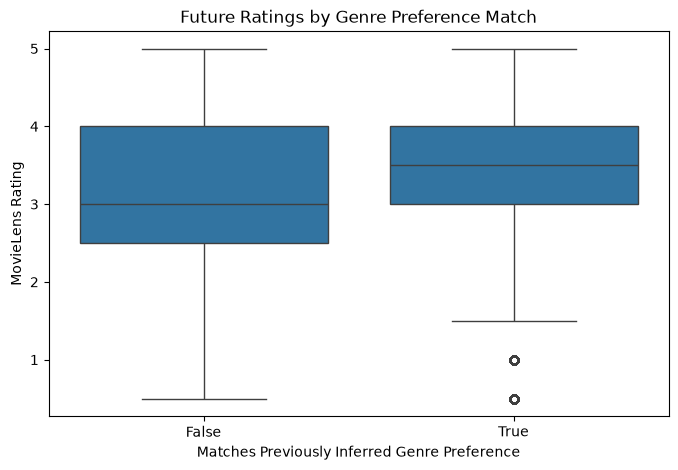

In [72]:
plt.figure(
    figsize=(8, 5)
)

sns.boxplot(
    data=test_ratings,
    x="preference_match",
    y="rating"
)

plt.title(
    "Future Ratings by Genre Preference Match"
)

plt.xlabel(
    "Matches Previously Inferred Genre Preference"
)

plt.ylabel(
    "MovieLens Rating"
)

plt.show()

### Hypothesis Test

The descriptive results show that preference-matching movies receive higher
ratings on average.

Because individual users contribute multiple ratings, treating every movie
rating as an independent observation would violate the independence
assumption of a standard two-group test.

Instead, the analysis calculates each user's average rating for:

- movies matching their previously inferred genre preferences
- movies not matching those preferences

Only users who have ratings in both groups are included.

A paired **Wilcoxon signed-rank test** is then used to determine whether
preference-matching movies tend to receive higher ratings.

**H₀:** Ratings for preference-matching movies are not higher.

**H₁:** Ratings for preference-matching movies are higher.

Significance level: **α = 0.05**

In [73]:
user_preference_ratings = (
    test_ratings
    .groupby(
        [
            "userId",
            "preference_match"
        ]
    )["rating"]
    .mean()
    .unstack()
)

user_preference_ratings.head()

preference_match,False,True
userId,,
1,4.461538,4.303030
2,4.833333,3.250000
3,0.500000,0.500000
4,3.250000,3.285714
5,4.000000,3.857143


In [74]:
paired_users = (
    user_preference_ratings
    .reindex(
        columns=[False, True]
    )
    .dropna()
    .copy()
)

paired_users.columns = [
    "non_matching_rating",
    "matching_rating"
]

print(
    f"Users with both types of ratings: "
    f"{len(paired_users)}"
)

paired_users.head()

Users with both types of ratings: 471


,non_matching_rating,matching_rating
userId,,
1,4.461538,4.303030
2,4.833333,3.250000
3,0.500000,0.500000
4,3.250000,3.285714
5,4.000000,3.857143


In [75]:
paired_users[
    "rating_difference"
] = (
    paired_users[
        "matching_rating"
    ]
    -
    paired_users[
        "non_matching_rating"
    ]
)

paired_users[
    "rating_difference"
].describe()

count    471.000000
mean       0.290531
std        0.767323
min       -2.000000
25%       -0.116477
50%        0.250000
75%        0.609127
max        4.166667
Name: rating_difference, dtype: float64

In [76]:
mean_difference = (
    paired_users[
        "rating_difference"
    ]
    .mean()
)

median_difference = (
    paired_users[
        "rating_difference"
    ]
    .median()
)

users_higher = (
    paired_users[
        "rating_difference"
    ] > 0
).mean()

users_equal = (
    paired_users[
        "rating_difference"
    ] == 0
).mean()

users_lower = (
    paired_users[
        "rating_difference"
    ] < 0
).mean()


print(
    f"Mean rating difference: "
    f"{mean_difference:.3f}"
)

print(
    f"Median rating difference: "
    f"{median_difference:.3f}"
)

print(
    f"Users rating matches higher: "
    f"{users_higher:.1%}"
)

print(
    f"Users rating both equally: "
    f"{users_equal:.1%}"
)

print(
    f"Users rating matches lower: "
    f"{users_lower:.1%}"
)

Mean rating difference: 0.291
Median rating difference: 0.250
Users rating matches higher: 68.8%
Users rating both equally: 2.8%
Users rating matches lower: 28.5%


In [77]:
wilcoxon_result = wilcoxon(
    paired_users[
        "matching_rating"
    ],
    paired_users[
        "non_matching_rating"
    ],
    alternative="greater"
)

print(
    f"Wilcoxon statistic: "
    f"{wilcoxon_result.statistic:.2f}"
)

print(
    f"P-value: "
    f"{wilcoxon_result.pvalue:.4e}"
)

Wilcoxon statistic: 76108.50
P-value: 4.7586e-17


In [78]:
alpha = 0.05

if wilcoxon_result.pvalue < alpha:

    print(
        "Reject the null hypothesis."
    )

    print(
        "There is statistically significant evidence "
        "that users rate movies matching their previously "
        "inferred genre preferences higher."
    )

else:

    print(
        "Fail to reject the null hypothesis."
    )

    print(
        "There is not enough statistical evidence "
        "to conclude that preference-matching movies "
        "receive higher ratings."
    )

Reject the null hypothesis.
There is statistically significant evidence that users rate movies matching their previously inferred genre preferences higher.


### Statistical Test Results

The analysis found that users tended to rate movies matching their previously
inferred genre preferences higher than non-matching movies.

At the user level:

- The **mean rating difference was +0.291** points.
- The **median rating difference was +0.250** points.
- **68.8% of users** rated preference-matching movies higher.
- **28.5% of users** rated non-matching movies higher.
- **2.8% of users** showed no difference.

The one-sided Wilcoxon signed-rank test produced:

- **Wilcoxon statistic:** 76,108.50
- **p-value:** 4.7586 × 10⁻¹⁷

Because the p-value is far below the significance level of 0.05, the null
hypothesis is rejected.

There is statistically significant evidence that users tend to give higher
future ratings to movies whose genres match preferences inferred from their
earlier rating history.

This result supports the use of historical genre preferences as one of the
signals in the recommendation system. The result represents an association
and does not imply that genre preference causes a higher rating.

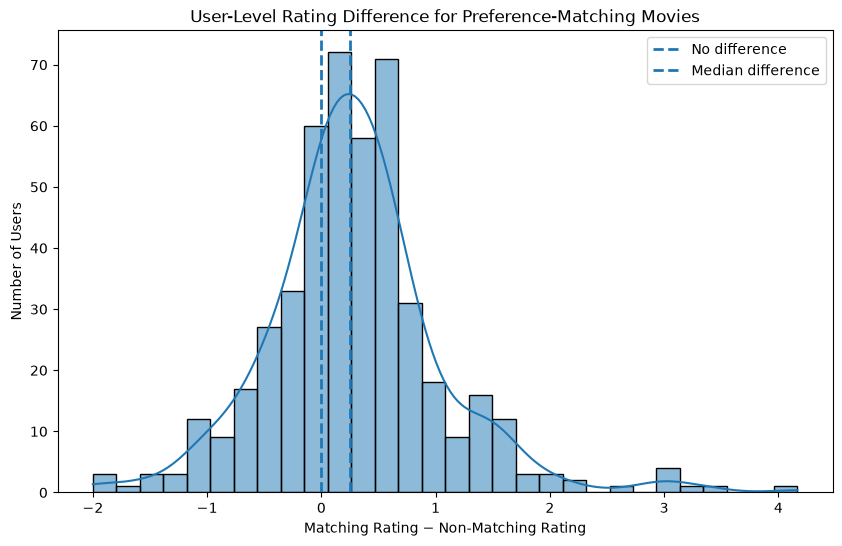

In [79]:
plt.figure(figsize=(10, 6))

sns.histplot(
    paired_users["rating_difference"],
    bins=30,
    kde=True
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="No difference"
)

plt.axvline(
    paired_users["rating_difference"].median(),
    linestyle="--",
    linewidth=2,
    label="Median difference"
)

plt.title(
    "User-Level Rating Difference for Preference-Matching Movies"
)

plt.xlabel(
    "Matching Rating − Non-Matching Rating"
)

plt.ylabel(
    "Number of Users"
)

plt.legend()

plt.show()

## Python and OOP Concepts Demonstrated

The recommendation system uses object-oriented programming throughout the
project.

- **Inheritance:** the specialized recommendation engines inherit from the
  `RecommendationEngine` base class.
- **Encapsulation:** recommendation datasets are stored in protected
  attributes such as `_ratings` and `_movies`.
- **Polymorphism:** different recommendation engines implement their own
  `recommend()` method while sharing the same interface.

The following section demonstrates polymorphism by calling the same method
on different recommendation-engine objects.

In [80]:
recommender_engines = [
    content_engine,
    collaborative_engine,
    cluster_engine
]

for engine in recommender_engines:

    print(
        f"\n{engine.__class__.__name__}"
    )

    results = engine.recommend(
        user_id=1,
        n=3
    )

    display(
        results[
            [
                "title",
                "genres"
            ]
        ]
    )


ContentBasedRecommender


,title,genres
232,"Shawshank Redemption, The (1994)",Crime|Drama
1137,Raging Bull (1980),Drama
2078,"Boot, Das (Boat, The) (1981)",Action|Drama|War



CollaborativeRecommender


,title,genres
53,The Imitation Game (2014),Drama|Thriller|War
52,Interstellar (2014),Sci-Fi|IMAX
6,"Shawshank Redemption, The (1994)",Crime|Drama



ClusterRecommender


,title,genres
277,Lone Star (1996),Drama|Mystery|Western
1021,Guess Who's Coming to Dinner (1967),Drama
353,Secrets & Lies (1996),Drama


### Functional Programming Examples

Python functional-programming tools can also be applied to recommendation
data. The examples below use `map`, `filter`, `lambda`, and `reduce` to
process the final recommendation results.

In [81]:
recommendation_titles = (
    hybrid_recommendations[
        "title"
    ]
    .tolist()
)

uppercase_titles = list(
    map(
        lambda title:
        title.upper(),
        recommendation_titles
    )
)

uppercase_titles[:5]

['SHAWSHANK REDEMPTION, THE (1994)',
 'DEPARTED, THE (2006)',
 "ONE FLEW OVER THE CUCKOO'S NEST (1975)",
 'CASABLANCA (1942)',
 'SPIRITED AWAY (SEN TO CHIHIRO NO KAMIKAKUSHI) (2001)']

In [82]:
recommendation_records = (
    hybrid_recommendations
    .to_dict(
        orient="records"
    )
)

three_model_recommendations = list(
    filter(
        lambda movie:
        movie[
            "models_recommending"
        ] == 3,
        recommendation_records
    )
)

for movie in three_model_recommendations:

    print(
        movie["title"]
    )

Shawshank Redemption, The (1994)
Departed, The (2006)
One Flew Over the Cuckoo's Nest (1975)
Casablanca (1942)
Spirited Away (Sen to Chihiro no kamikakushi) (2001)
Whiplash (2014)
Pianist, The (2002)
Godfather, The (1972)
Léon: The Professional (a.k.a. The Professional) (Léon) (1994)


In [83]:
# reduce combines a sequence into one value; here it totals how many model
# votes support the final recommendation list.
total_model_votes = reduce(
    lambda total, movie: total + int(movie["models_recommending"]),
    recommendation_records,
    0
)

print(f"Total model votes across the final list: {total_model_votes}")

Total model votes across the final list: 29


These functional-programming examples are included to demonstrate Python
techniques covered in the course. Pandas operations are used for most
large-scale data processing because they are more appropriate for tabular
data.

## Recommendation System Summary

The recommendation engine is now complete.

The system combines three complementary recommendation approaches:

1. **Content-based filtering** using genre, director, and movie-rating
   information.
2. **Collaborative filtering** using SciPy Pearson correlation between
   users with shared movie ratings.
3. **Cluster-based filtering** using SciPy k-means clustering of user
   genre preferences.

These signals are combined by the `HybridRecommender`, which produces a
single ranked list of personalized movie recommendations.

A rule-based explanation component generates human-readable reasons for
each recommendation using the user's actual rating history.

Statistical testing using a chronological train/test split also found that
movies matching preferences inferred from earlier ratings received
significantly higher later ratings.

The next notebook presents the completed system as a user-facing movie
recommendation demo.

In [84]:
# Persist cluster labels for the standalone demo notebook.
user_clusters.to_csv(
    "data/processed/user_clusters.csv",
    index=False
)

print("User clusters saved.")

User clusters saved.


In [85]:
# Save normalized date formatting after the notebook's transformations.
movie_ratings.to_csv(
    "data/processed/movie_ratings.csv",
    index=False
)